# Predicting Fatal Motor Vehicle Collisions in Toronto: A Machine Learning Approach Using the KSI Dataset (2006–2026)

**Course:** 26W_CST2109_Machine Learning

**Authors:** Duc Anh Ngo (040943725), Ngan Nguyen (041154207)


In [1]:
# Import Libraries
import pandas as pd
pd.set_option('display.max_columns', 100)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score,accuracy_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

In [2]:
# Load Raw Dataset
df_raw = pd.read_csv('Motor Vehicle Collisions with KSI Data.csv')
print("Raw data shape:",df_raw.shape)
print("Columns:", df_raw.columns)

Raw data shape: (20455, 50)
Columns: Index(['_id', 'collision_id', 'accdate', 'stname1', 'stname2', 'stname3',
       'per_inv', 'acclass', 'accloc', 'traffictl', 'impactype', 'visible',
       'light', 'rdsfcond', 'road_class', 'failtorem', 'longitude', 'latitude',
       'veh_no', 'vehtype', 'initdir', 'per_no', 'invage', 'injury',
       'safequip', 'drivact', 'drivcond', 'pedact', 'pedcond', 'manoeuvre',
       'pedtype', 'cyclistype', 'cycact', 'cyccond', 'road_user', 'fatal_no',
       'wardname', 'division', 'neighbourhood', 'aggressive', 'distracted',
       'cyclist', 'motorcyclist', 'other_micromobility', 'older_adult',
       'pedestrian', 'red_light', 'school_child', 'heavy_truck', 'geometry'],
      dtype='object')


In [3]:
# Check Column Data Types
df_raw.dtypes

_id                      int64
collision_id            object
accdate                 object
stname1                 object
stname2                 object
stname3                 object
per_inv                  int64
acclass                 object
accloc                  object
traffictl               object
impactype               object
visible                 object
light                   object
rdsfcond                object
road_class              object
failtorem                 bool
longitude              float64
latitude               float64
veh_no                 float64
vehtype                 object
initdir                 object
per_no                 float64
invage                 float64
injury                  object
safequip                object
drivact                 object
drivcond                object
pedact                  object
pedcond                 object
manoeuvre               object
pedtype                 object
cyclistype              object
cycact  

In [4]:
# Preview Raw Data (Sample 10 Rows)
df_raw.sample(10)

,_id,collision_id,accdate,stname1,stname2,stname3,per_inv,acclass,accloc,traffictl,impactype,visible,light,rdsfcond,road_class,failtorem,longitude,latitude,veh_no,vehtype,initdir,per_no,invage,injury,safequip,drivact,drivcond,pedact,pedcond,manoeuvre,pedtype,cyclistype,cycact,cyccond,road_user,fatal_no,wardname,division,neighbourhood,aggressive,distracted,cyclist,motorcyclist,other_micromobility,older_adult,pedestrian,red_light,school_child,heavy_truck,geometry
19150,19151,2024:4000431448,2024-02-26T17:34:00,BIRCHMOUNT RD,ST CLAIR AVE E,NaN,6,Fatal Injury,Intersection-Related,No Control,Cyclist Collision,Clear,Daylight,Dry,Major Arterial,False,-79.273716,43.713564,2.0,Automobile or Station Wagon,West,5.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,passenger,NaN,Scarborough Southwest (20),41 Division,Clairlea-Birchmount,False,True,True,False,False,False,False,False,False,False,"{""coordinates"": [[-79.2737163661758, 43.713564..."
8512,8513,2012:1311498,2012-07-20T13:00:00,QUEENS QUAY W,LOWER SIMCOE ST,NaN,4,Non-Fatal Injury,At Intersection,Traffic Signal,Rear End,Clear,Daylight,Dry,Minor Arterial,False,-79.382691,43.639544,2.0,NaN,NaN,10.0,51.0,Minimal,No Equipment Available,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,passenger,NaN,Spadina-Fort York (10),52 Division,Harbourfront-CityPlace,False,True,False,False,False,True,False,False,True,True,"{""coordinates"": [[-79.38269089226492, 43.63954..."
11424,11425,2016:6001707155,2016-09-25T16:29:00,KEELE ST,STEELES AVE W,NaN,6,Non-Fatal Injury,At Intersection,Traffic Signal,Angle,Clear,Daylight,Dry,Major Arterial,False,-79.494465,43.781507,2.0,NaN,NaN,4.0,58.0,Minor,Lap and Shoulder Belt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,passenger,NaN,York Centre (6),31 Division,York University Heights,True,True,False,False,False,True,False,True,False,False,"{""coordinates"": [[-79.49446487267393, 43.78150..."
14993,14994,2018:8001752003,2018-09-21T17:23:00,WOODBINE TRACK ACCESS,REXDALE BLVD,150 m South of,6,Non-Fatal Injury,Non-Intersection,No Control,Turning Movement,Rain,Daylight,Wet,Local,False,-79.603444,43.717654,1.0,NaN,NaN,3.0,40.0,NaN,Lap and Shoulder Belt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,passenger,NaN,Etobicoke North (1),23 Division,West Humber-Clairville,False,False,False,False,False,True,False,False,False,True,"{""coordinates"": [[-79.60344406650272, 43.71765..."
5738,5739,2010:1161157,2010-04-07T15:45:00,DUNDAS St W,BLOOR St W,NaN,1,Non-Fatal Injury,At Intersection,No Control,Pedestrian Collision(internal code),Rain,Daylight,Wet,Minor Arterial,False,-79.452091,43.655144,2.0,NaN,East,2.0,71.0,Major,Other Safety Equipment Used,NaN,NaN,Crossing - no traffic control,Inattentive,NaN,Driver hits pedestrian at midblock,NaN,NaN,NaN,pedestrian,NaN,Parkdale-High Park (4),11 Division,Roncesvalles,False,True,False,False,False,True,True,False,False,False,"{""coordinates"": [[-79.45209100325717, 43.65514..."
2640,2641,2007:995821,2007-09-29T16:00:00,WESTON RD,KNOB HILL DR,NaN,4,Non-Fatal Injury,At Intersection,Stop Sign,Angle,Clear,Daylight,Dry,Major Arterial,False,-79.535191,43.711244,2.0,NaN,NaN,3.0,55.0,Minor,Lap and Shoulder Belt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,passenger,NaN,York South-Weston (5),12 Division,Pelmo Park-Humberlea,True,True,False,False,False,False,False,False,False,False,"{""coordinates"": [[-79.5351910377574, 43.711244..."
12428,12429,2016:6000477912,2016-03-20T03:03:00,BAY ST,WELLINGTON ST W,NaN,8,Non-Fatal Injury,At Intersection,Traffic Signal,Angle,Clear,Dark with Artificial Lighting,Dry,Major Arterial,False,-79.379727,43.647318,2.0,NaN,NaN,7.0,32.0,Major,Lap and Shoulder Belt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,passenger,NaN,Spadina-Fort York (10),52 Division,Yonge-Bay Corridor,True,False,False,False,False,False,False,True,True,False,"{""coordinates"": [[-79.37972687458937, 43.64731..."
12326,12327,2016:6000133147,2016-01-23T00:35:00,BATHURST ST,FORT YORK BLVD,NaN,12,Non-Fatal Injury,At Intersection,Traffic Signal,Turning Movement,Clear,Dark with Artificial Lighting,Dry,

In [5]:
# Explore Target & Leakage Columns
print("acclass values:")
print(df_raw["acclass"].value_counts())
print("-"*40)
print("injury values:")
print(df_raw["injury"].value_counts())
print()
print("fatal_no values:")
print(df_raw["fatal_no"].value_counts())

print()
print("==>This injury & fatal_no columns LEAKS the answer -> overfiting -> We need to drop it")

acclass values:
acclass
Non-Fatal Injury        17550
Fatal Injury             2886
Property Damage Only       18
Name: count, dtype: int64
----------------------------------------
injury values:
injury
Major      7005
Minor      1573
Minimal    1220
Fatal      1073
Name: count, dtype: int64

fatal_no values:
fatal_no
22.0    24
11.0    24
7.0     21
2.0     21
8.0     21
        ..
70.0     1
69.0     1
68.0     1
78.0     1
77.0     1
Name: count, Length: 78, dtype: int64

==>This injury & fatal_no columns LEAKS the answer -> overfiting -> We need to drop it


## Step 1 - Data Cleaning
### 1. Create the Target Variable IS_FATAL
- **Fatal -> IS_FATAL = 1**
- **Non-Fatal -> IS_FATAL = 0**
- **Property Damage -> Remove** (we do not need it on dataset)

In [6]:
# Create Target Variable IS_FATAL
df = df_raw[df_raw["acclass"] != "Property Damage Only"].copy()
df = df.dropna(subset = ["acclass"])

#create IS_FATAL target variable
df['IS_FATAL'] = (df['acclass'] == "Fatal Injury").astype(int)
print("Row after remove 'Property Damage Only':", len(df))
print("-"*10)
print("IS_FATAL values: ")
print(df['IS_FATAL'].value_counts())
print("-"*10)
print(f"Fatal rate: {df['IS_FATAL'].mean():.1%}")

Row after remove 'Property Damage Only': 20436
----------
IS_FATAL values: 
IS_FATAL
0    17550
1     2886
Name: count, dtype: int64
----------
Fatal rate: 14.1%


### 2. Drop Data-Leakage Columns

In [7]:
# Drop Leakage Columns
LEAK_COLS = ["injury","fatal_no","acclass"]
df = df.drop(columns = LEAK_COLS, errors = "ignore")
print("Dropped leakage columns successful!", LEAK_COLS)

Dropped leakage columns successful! ['injury', 'fatal_no', 'acclass']


In [8]:
# Preview Data After Dropping Leakage Columns
df.head(2)

,_id,collision_id,accdate,stname1,stname2,stname3,per_inv,accloc,traffictl,impactype,visible,light,rdsfcond,road_class,failtorem,longitude,latitude,veh_no,vehtype,initdir,per_no,invage,safequip,drivact,drivcond,pedact,pedcond,manoeuvre,pedtype,cyclistype,cycact,cyccond,road_user,wardname,division,neighbourhood,aggressive,distracted,cyclist,motorcyclist,other_micromobility,older_adult,pedestrian,red_light,school_child,heavy_truck,geometry,IS_FATAL
0,1,2006:893184,2006-01-01T02:36:00,WOODBINE AVE,O CONNOR DR,NaN,8,Intersection-Related,No Control,Approaching Head On,Clear,Dark,Wet,Major Arterial,False,-79.318798,43.699594,2.0,NaN,NaN,4.0,19.0,Equipment Not Used But Available,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,passenger,Beaches-East York (19),55 Division,Woodbine-Lumsden,False,False,False,False,False,False,False,False,True,False,"{""coordinates"": [[-79.31879768423914, 43.69959...",0
1,2,2006:893184,2006-01-01T02:36:00,WOODBINE AVE,O CONNOR DR,NaN,8,Intersection-Related,No Control,Approaching Head On,Clear,Dark,Wet,Major Arterial,False,-79.318798,43.699594,1.0,Automobile or Station Wagon,North,2.0,55.0,Lap and Shoulder Belt,Driving properly,Normal,NaN,NaN,Going Ahead,NaN,NaN,NaN,NaN,driver,Beaches-East York (19),55 Division,Woodbine-Lumsden,False,False,False,False,False,False,False,False,True,False,"{""coordinates"": [[-79.31879768423914, 43.69959...",0


### 3. Encode Boolean (True/False) -> 1/0

In [9]:
# Encode Boolean Flag Columns (True/False -> 1/0)
FLAG_COLS = ["failtorem","aggressive","distracted","cyclist", "motorcyclist","other_micromobility",
             "older_adult","pedestrian","red_light","school_child","heavy_truck"]
for col in FLAG_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(int)
print("Convert successful!")

Convert successful!


In [10]:
# Pre-Aggregation Check: Unique Values Per Collision
#check columns before aggregation
df.groupby("collision_id")["drivact"].nunique().max()

3

### 4. Aggregate from Person-Level to Collision-Level
**We checked each column before aggregation by using groupby for each collision_id with nunique()**

`df.groupby("collision_id")["column_name"].nunique().max()`


In [11]:
# Define Aggregation Rules
COLLISION_COLS = ["accdate","stname1","stname2","accloc","traffictl","impactype","visible", "light","rdsfcond","road_class","failtorem","longitude",
                  "latitude","wardname","division","neighbourhood","aggressive","distracted","cyclist","motorcyclist",
                  "red_light","school_child","heavy_truck","older_adult","pedestrian"]
agg_dict = {}
for col in COLLISION_COLS:
    agg_dict[col] = "first" #get the first value for all persons in collision
agg_dict['IS_FATAL'] = "max" #1 if any person died in collision
agg_dict["per_inv"] = "max" # total of number people involved

In [12]:
# Explore Driver Condition & Action Values
print(df["drivcond"].value_counts())
print("-"*100)
print(df["drivact"].unique())

drivcond
Normal                                                    6797
Inattentive                                               1610
Unknown                                                   1192
Medical or Physical Disability                             185
Had Been Drinking                                          175
Ability Impaired - Alcohol Over .08                        140
Other Condition                                            139
Ability Impaired - Alcohol                                 125
Fatigue/Fell Asleep                                         64
Inattentive - Other                                         43
Ability Impaired - Drugs                                    20
Medical or Physical Disability - Sudden Incapacitation      10
Medical or Physical Disability - Other                       5
Road Rage/Aggression                                         5
Ability Impaired - Other Drugs                               3
Medical or Physical Disability - Cognitive Imp

In [13]:
# Engineer BAD_DRIVCOND Feature
if "drivcond" in df.columns:
    BAD_VALS = ["Inattentive","Had Been Drinking","Ability Impaired - Alcohol Over .08",
                "Ability Impaired - Alcohol","Ability Impaired - Drugs","Ability Impaired - Other Drugs",
                "Road Rage/Aggression","Fatigue/Fell Asleep","Inattentive - Other"]
    df["BAD_DRIVCOND"] = df["drivcond"].isin(BAD_VALS).astype(int)
    agg_dict["BAD_DRIVCOND"] = "max"

In [14]:
# Engineer BAD_DRIVACT Feature
if "drivact" in df.columns:
    BAD_ACTS = ["Lost control","Improper lane change","Disobeyed traffic control",
                "Failed to yield right-of-way","Speed too fast for conditions","Exceeding speed limit",
                "Improper turn","Following too closely","Improper passing","Wrong way on one-way road"]
    df["BAD_DRIVACT"] = df["drivact"].isin(BAD_ACTS).astype(int)
    agg_dict["BAD_DRIVACT"] = "max"

In [15]:
# Preview Data Before Aggregation
df.sample(5)

,_id,collision_id,accdate,stname1,stname2,stname3,per_inv,accloc,traffictl,impactype,visible,light,rdsfcond,road_class,failtorem,longitude,latitude,veh_no,vehtype,initdir,per_no,invage,safequip,drivact,drivcond,pedact,pedcond,manoeuvre,pedtype,cyclistype,cycact,cyccond,road_user,wardname,division,neighbourhood,aggressive,distracted,cyclist,motorcyclist,other_micromobility,older_adult,pedestrian,red_light,school_child,heavy_truck,geometry,IS_FATAL,BAD_DRIVCOND,BAD_DRIVACT
12335,12336,2016:6000143502,2016-01-24T21:41:00,EGLINTON AVE E,MASON RD,NaN,2,At Intersection,Traffic Signal,Pedestrian Collision(internal code),Clear,Dark with Artificial Lighting,Dry,Major Arterial,0,-79.225154,43.741781,1.0,NaN,Unknown,2.0,37.0,Use Unknown,NaN,NaN,Crossing without right-of-way (intersection),Inattentive,NaN,Driver going straight hits pedestrian crossing...,NaN,NaN,NaN,pedestrian,Scarborough Southwest (20),43 Division,Scarborough Village,0,1,0,0,0,1,1,0,0,0,"{""coordinates"": [[-79.22515447392053, 43.74178...",0,0,0
19850,19851,2025:5000744673,2025-04-10T14:13:00,QUEEN ST E,KING ST E,NaN,2,Intersection-Related,NaN,Turning Movement,Rain,Daylight with Artificial Lighting,Wet,Major Arterial,0,-79.354924,43.657744,2.0,Pickup Truck,East,2.0,75.0,Lap and Shoulder Belt,Driving properly,Normal,NaN,NaN,Going Ahead,NaN,NaN,NaN,NaN,driver,Toronto Centre (13),51 Division,Moss Park,0,0,1,0,0,1,0,0,0,0,"{""coordinates"": [[-79.35492381077404, 43.65774...",0,0,0
3620,3621,2008:1047910,2008-07-14T13:37:00,DANFORTH AVE,COXWELL AVE,NaN,10,At Intersection,Traffic Signal,Pedestrian Collision(internal code),Clear,Daylight,Dry,Major Arterial,0,-79.323591,43.683344,3.0,NaN,NaN,3.0,11.0,Lap and Shoulder Belt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,passenger,Beaches-East York (19),55 Division,Woodbine Corridor,1,0,0,0,0,0,1,0,1,0,"{""coordinates"": [[-79.3235907151712, 43.683344...",1,0,0
8304,8305,2012:1304939,2012-05-30T13:15:00,DUNDAS ST W,MANNING AVE,NaN,2,At Intersection,Traffic Signal,Cyclist Collision,Clear,Daylight,Dry,Major Arterial,0,-79.410891,43.651344,1.0,Automobile or Station Wagon,East,1.0,26.0,Lap and Shoulder Belt,Driving properly,Normal,NaN,NaN,Stopped,NaN,NaN,NaN,NaN,driver,University-Rosedale (11),14 Division,Trinity-Bellwoods,0,0,1,0,0,0,0,0,0,0,"{""coordinates"": [[-79.4108909293251, 43.651344...",0,0,0
5352,5353,2009:1144951,2009-12-06T07:50:00,EGLINTON AVE W,EXPLORER DR,NaN,4,At Intersection,Traffic Signal,Rear End,Clear,Daylight,Dry,Major Arterial,0,-79.594091,43.659744,2.0,NaN,NaN,2.0,NaN,Other Safety Equipment Used,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,owner,Etobicoke Centre (2),22 Division,Eringate-Centennial-West Deane,1,0,0,0,0,0,0,0,1,0,"{""coordinates"": [[-79.59409120984716, 43.65974...",0,0,0


In [16]:
# Aggregate Person-Level to Collision-Level
df_coll = df.groupby("collision_id").agg(agg_dict).reset_index(drop=True)
print(f"Collision-level: {len(df_coll)} rows after groupby")
print("-"*30)
print(df_coll["IS_FATAL"].value_counts())
print("-"*30)
print(f"Fatal rate: {df_coll["IS_FATAL"].mean():.1%}")

Collision-level: 7480 rows after groupby
------------------------------
IS_FATAL
0    6439
1    1041
Name: count, dtype: int64
------------------------------
Fatal rate: 13.9%


## Step 2 - Feature Engineering

In [17]:
# Convert accdate to Datetime Format
df_coll["accdate"] = pd.to_datetime(df_coll["accdate"],errors = "coerce") #convert accdate from object to datetime
print(df_coll["accdate"].dtypes)

datetime64[ns]


In [18]:
# Extract Temporal Features (YEAR, MONTH, DAY_OF_WEEK, WEEKEND, HOUR)
df_coll['YEAR'] = df_coll["accdate"].dt.year
df_coll['MONTH'] = df_coll["accdate"].dt.month
df_coll['DAY_OF_WEEK'] = df_coll["accdate"].dt.dayofweek #0 = Mon, 1 = Tues, 2 = Wed, ..... 6 = Sun
df_coll['WEEKEND'] = (df_coll["DAY_OF_WEEK"] >= 5).astype(int)
df_coll['HOUR'] = df_coll["accdate"].dt.hour
df_coll.sample(5)

,accdate,stname1,stname2,accloc,traffictl,impactype,visible,light,rdsfcond,road_class,failtorem,longitude,latitude,wardname,division,neighbourhood,aggressive,distracted,cyclist,motorcyclist,red_light,school_child,heavy_truck,older_adult,pedestrian,IS_FATAL,per_inv,BAD_DRIVCOND,BAD_DRIVACT,YEAR,MONTH,DAY_OF_WEEK,WEEKEND,HOUR
746,2007-02-12 08:50:00,BRIMLEY RD,PITFIELD RD,At Intersection,Traffic Signal,Cyclist Collision,Snow,Daylight,Loose Snow,Major Arterial,0,-79.266390,43.783444,Scarborough North (23),42 Division,Agincourt South-Malvern West,0,0,1,0,0,0,0,0,0,0,2,0,0,2007,2,0,0,8
4079,2015-10-10 19:19:00,ISLINGTON AVE,DEERFOOT RD,None,No Control,Pedestrian Collision(internal code),Clear,Dark,Dry,Major Arterial,0,-79.541394,43.685213,Etobicoke Centre (2),23 Division,Willowridge-Martingrove-Richview,1,1,0,0,0,0,0,0,1,1,3,1,1,2015,10,5,1,19
3347,2013-08-17 02:28:00,BLOOR ST W,CLINTON ST,None,No Control,Turning Movement,Clear,Dark,Dry,Major Arterial,0,-79.417210,43.663824,University-Rosedale (11),14 Division,Palmerston-Little Italy,0,0,0,0,0,1,0,0,0,0,5,1,1,2013,8,5,1,2
5974,2020-11-13 12:45:00,GERVAIS DR,WYNFORD DR,Non-Intersection,No Control,Approaching Head On,Clear,Daylight,Dry,Collector,0,-79.336979,43.724161,Don Valley East (16),33 Division,Banbury-Don Mills,0,0,0,0,0,0,0,1,0,0,2,0,1,2020,11,4,0,12
1128,2008-05-28 23:10:00,LAWRENCE AVE W,LAWRENCE W ALLEN X S RAMP,At Intersection,Traffic Signal,Turning Movement,Clear,Dark,Dry,Major Arterial,0,-79.444991,43.715944,Eglinton-Lawrence (8),13 Division,Yorkdale-Glen Park,1,1,0,0,0,0,0,1,0,0,3,1,1,2008,5,2,0,23


In [19]:
# Verify New Temporal Features
df_coll[["YEAR","MONTH","HOUR","WEEKEND"]].describe()

,YEAR,MONTH,HOUR,WEEKEND
count,7480.000000,7480.000000,7480.000000,7480.000000
mean,2014.655080,6.870455,13.426604,0.266310
std,5.693703,3.289106,6.269472,0.442058
min,2006.000000,1.000000,0.000000,0.000000
25%,2010.000000,4.000000,9.000000,0.000000
50%,2014.000000,7.000000,14.000000,0.000000
75%,2019.000000,10.000000,18.000000,1.000000
max,2026.000000,12.000000,23.000000,1.000000


## Step 3 - Exploratory Data Analysis (EDA)

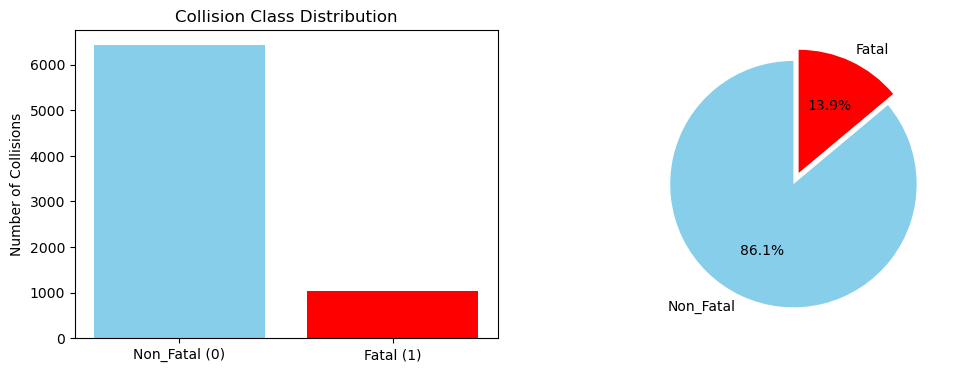

In [20]:
# Chart 1 - Class Distribution (Fatal vs Non-Fatal)
fig,axes = plt.subplots(1,2, figsize = (12,4))
count_fatal = df_coll['IS_FATAL'].value_counts()
axes[0].bar(["Non_Fatal (0)", "Fatal (1)"], count_fatal.values, color = ['skyblue','red'])
axes[0].set_title("Collision Class Distribution")
axes[0].set_ylabel("Number of Collisions")

axes[1].pie(count_fatal.values, labels = ['Non_Fatal','Fatal'], colors = ['skyblue','red'], autopct = "%1.1f%%", startangle = 90, explode = (0,0.1))
plt.show()

**Chart 1 - Class Distribution**

This chart shows how many collisions are Fatal vs Non-Fatal in our dataset. We can see the data is heavily imbalanced that Fatal collisions are only about 14% of all collisions. This is a problem because if we train a model on this unbalanced data, it will just learn to always predict Non-Fatal and still get ~86% accuracy, but it would completely miss all the fatal cases. That is why we need to use SMOTE later to fix this imbalance.

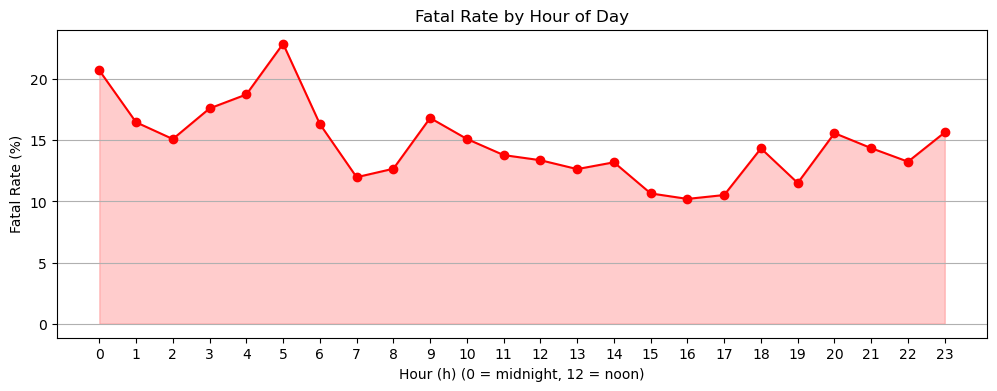

In [21]:
# Chart 2 - Fatal Rate by Hour of Day
hourly = df_coll.groupby("HOUR")["IS_FATAL"].mean()

plt.figure(figsize = (12,4))
plt.plot(hourly.index, hourly.values*100, marker = "o", color = "red", linewidth = 1.5)
plt.fill_between(hourly.index, hourly.values*100, alpha = 0.2, color = "red")
plt.xticks(range(0,24))
plt.title("Fatal Rate by Hour of Day")
plt.xlabel("Hour (h) (0 = midnight, 12 = noon)")
plt.ylabel("Fatal Rate (%)")
plt.grid(axis = "y")
plt.show()

**Chart 2 - Fatal Rate by Hour of Day**

This chart shows the percentage of collisions that turn fatal at each hour of the day. We can see that late night and early morning hours (around 8 PM to 5 AM) have the highest fatal rates. This makes sense because late-night driving often involves speeding, impaired drivers, and less traffic control. This finding tells the City of Toronto that increasing patrols or awareness campaigns during these hours could help reduce deaths.

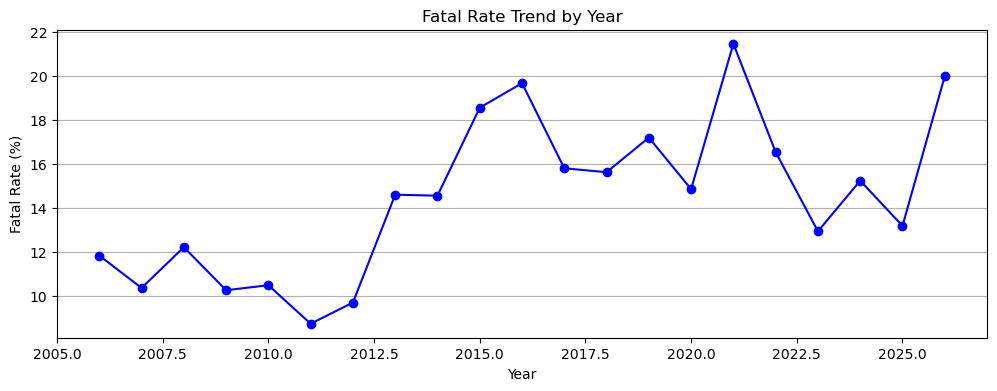

In [22]:
# Chart 3 - Fatal Rate Trend by Year
yearly = df_coll.groupby("YEAR")["IS_FATAL"].mean()
plt.figure(figsize = (12,4))
plt.plot(yearly.index, yearly.values*100, marker = "o", color = "blue", linewidth = 1.5)
plt.title("Fatal Rate Trend by Year")
plt.xlabel("Year")
plt.ylabel("Fatal Rate (%)")
plt.grid(axis = "y")
plt.show()

**Chart 3 - Fatal Rate Trend by Year**

This chart shows how the fatal rate has changed from 2006 to 2026. We can see the fatal rate has been going up since around 2016-2017. This is a worrying trend. 

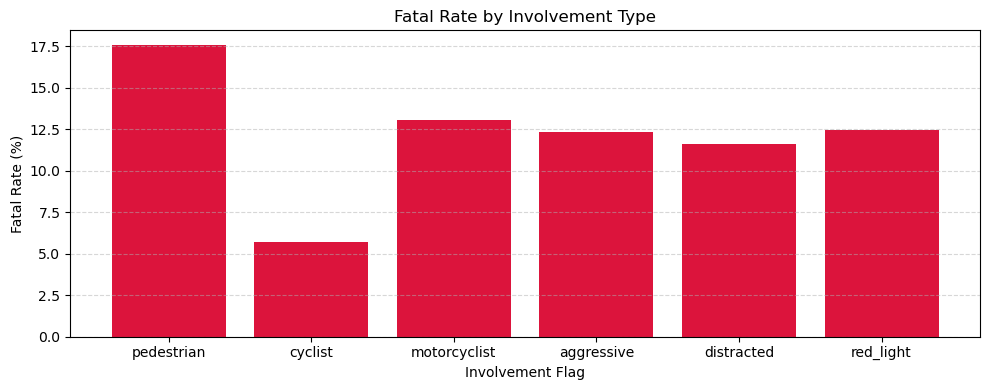

In [23]:
# Fatal rate by involvement type
involve_cols = ["pedestrian","cyclist","motorcyclist","aggressive","distracted","red_light"]
fatal_rates = {col: df_coll[df_coll[col]==1]["IS_FATAL"].mean()*100 for col in involve_cols if col in df_coll.columns}

plt.figure(figsize=(10, 4))
plt.bar(fatal_rates.keys(), fatal_rates.values(), color="crimson")
plt.title("Fatal Rate by Involvement Type")
plt.ylabel("Fatal Rate (%)")
plt.xlabel("Involvement Flag")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Chart 4 - Fatal Rate by Involvement Type**

This chart shows which type of road users have the highest fatal rate when involved in a collision. Pedestrians and motorcyclists have the highest fatal rate compared to cyclists or distracted drivers. This makes sense because pedestrians and motorcyclists have no physical protection in a crash. This chart also justifies why we included pedestrian, motorcyclist, and cyclist as features in our model, they clearly have a strong connection to fatality.

## Step 4 - Prepare Features for Model

In [24]:
# Check Data Types & Save Collision-Level Dataset
df_coll.dtypes
df_coll.to_csv("Step1-4 New Version.csv", index = False)

In [25]:
# Define Feature Groups & Handle Missing Values
#category column
CATEGORICAL_COLS = ["accloc","traffictl","impactype","visible","light","rdsfcond","road_class","wardname"]
#numeric column
NUM_COLS = ["YEAR","MONTH","DAY_OF_WEEK","WEEKEND","HOUR"]
#binary column
BIN_COLS = ["pedestrian","older_adult","heavy_truck","school_child","red_light","motorcyclist","cyclist","aggressive","distracted"]
#Aggrate column
AGG_COLS = ["per_inv","BAD_DRIVCOND","BAD_DRIVACT"]
#save new dataset as feature dataset
ALL_NEED_FEATURES = CATEGORICAL_COLS + NUM_COLS + BIN_COLS + AGG_COLS
df_features = df_coll[ALL_NEED_FEATURES + ["IS_FATAL"]].copy()
print("Features dataset with null values:")
print(df_features.isnull().sum())
print("-"*20)

#after we check, just only null values on categorical columns -> We have to handle it
for col in CATEGORICAL_COLS:
    df_features[col] = df_features[col].fillna("Unknown")
print("Features dataset without null values after we handled it:")    
print(df_features.isnull().sum())

Features dataset with null values:
accloc          1841
traffictl         84
impactype         10
visible           20
light             10
rdsfcond          22
road_class       236
wardname          39
YEAR               0
MONTH              0
DAY_OF_WEEK        0
WEEKEND            0
HOUR               0
pedestrian         0
older_adult        0
heavy_truck        0
school_child       0
red_light          0
motorcyclist       0
cyclist            0
aggressive         0
distracted         0
per_inv            0
BAD_DRIVCOND       0
BAD_DRIVACT        0
IS_FATAL           0
dtype: int64
--------------------
Features dataset without null values after we handled it:
accloc          0
traffictl       0
impactype       0
visible         0
light           0
rdsfcond        0
road_class      0
wardname        0
YEAR            0
MONTH           0
DAY_OF_WEEK     0
WEEKEND         0
HOUR            0
pedestrian      0
older_adult     0
heavy_truck     0
school_child    0
red_light       0
mot

In [26]:
# One-Hot Encode Categorical Columns
#convert category columns into 0/1 by using dummies
df_encoded  = pd.get_dummies(df_features, columns = CATEGORICAL_COLS, drop_first = False)
print(f"New shape of dataset after encoded: {df_encoded.shape}")
df_encoded.sample(5)

New shape of dataset after encoded: (7480, 132)


,YEAR,MONTH,DAY_OF_WEEK,WEEKEND,HOUR,pedestrian,older_adult,heavy_truck,school_child,red_light,motorcyclist,cyclist,aggressive,distracted,per_inv,BAD_DRIVCOND,BAD_DRIVACT,IS_FATAL,accloc_At Intersection,accloc_At Railway Crossing,accloc_At/Near Private Drive,accloc_Four-way,accloc_Intersection-Related,accloc_Laneway,accloc_Non-Intersection,accloc_Offset,accloc_Other Intersection,accloc_Overpass or Bridge,accloc_Private Driveway,accloc_Roundabout,accloc_T Intersection,accloc_Trail,accloc_Underpass or Tunnel,accloc_Unknown,accloc_Y Intersection,traffictl_Half Signal,traffictl_No Control,traffictl_Other,traffictl_Pedestrian Crossover,traffictl_Pedestrian Signal,traffictl_Police Control,traffictl_School Guard,traffictl_Stop Sign,traffictl_Streetcar (Stop for),traffictl_Traffic Controller,traffictl_Traffic Gate,traffictl_Traffic Signal,traffictl_Unknown,traffictl_Yield Sign,impactype_Angle,...,light_Unknown,rdsfcond_Dry,rdsfcond_Ice,rdsfcond_Loose Sand or Gravel,rdsfcond_Loose Snow,rdsfcond_Other,rdsfcond_Packed Snow,rdsfcond_Slush,rdsfcond_Spilled Liquid,rdsfcond_Unknown,rdsfcond_Wet,road_class_Collector,road_class_Expressway,road_class_Expressway Ramp,road_class_Laneway,road_class_Local,road_class_Major Arterial,road_class_Major Arterial Ramp,road_class_Major Shoreline,road_class_Minor Arterial,road_class_Other,road_class_Pending,road_class_Private Property,road_class_Unknown,wardname_Beaches-East York (19),wardname_Davenport (9),wardname_Don Valley East (16),wardname_Don Valley North (17),wardname_Don Valley West (15),wardname_Eglinton-Lawrence (8),wardname_Etobicoke Centre (2),wardname_Etobicoke North (1),wardname_Etobicoke-Lakeshore (3),wardname_Humber River-Black Creek (7),wardname_Parkdale-High Park (4),wardname_Scarborough Centre (21),wardname_Scarborough North (23),wardname_Scarborough Southwest (20),wardname_Scarborough-Agincourt (22),wardname_Scarborough-Guildwood (24),wardname_Scarborough-Rouge Park (25),wardname_Spadina-Fort York (10),wardname_Toronto Centre (13),wardname_Toronto-Danforth (14),wardname_Toronto-St. Paul's (12),wardname_University-Rosedale (11),wardname_Unknown,wardname_Willowdale (18),wardname_York Centre (6),wardname_York South-Weston (5)
4629,2017,3,6,1,13,0,1,0,0,1,0,0,1,1,8,1,1,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3792,2014,12,1,0,14,0,0,1,0,0,0,0,0,0,2,0,1,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5806,2020,4,4,0,23,0,0,0,0,0,0,0,0,0,4,0,1,1,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4688,2017,5,0,0,18,1,0,0,1,0,0,0,0,0,2,0,0,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,Fa

## Step 5 - Handle Imbalance with SMOTE

In [27]:
# Split Data into Train/Test Sets (80/20 Stratified)
X = df_encoded .drop(columns = ["IS_FATAL"])
y = df_encoded["IS_FATAL"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y) # use strafity = y to make sure train and test is the same with imbalance data


In [28]:
# Apply SMOTE to Training Data Only
# Run SMOTE on training data only
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

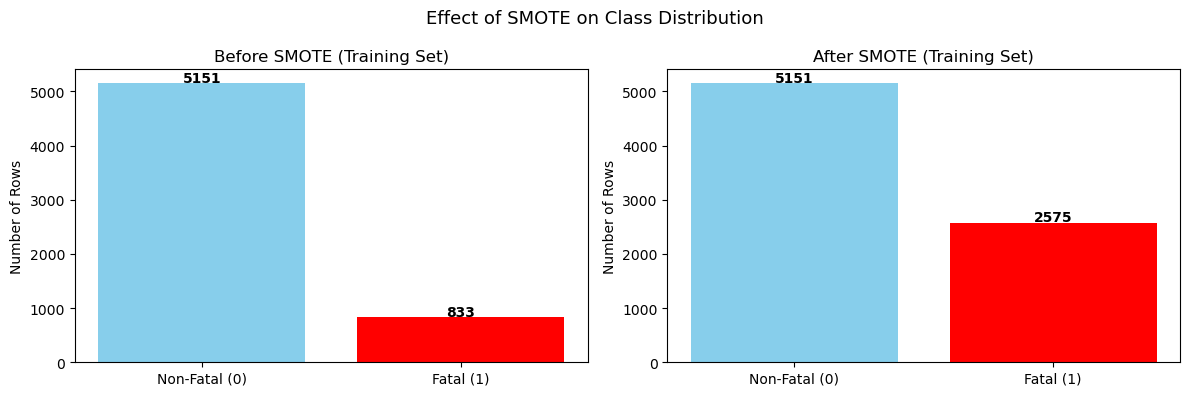

Before SMOTE — Non-Fatal: 5151, Fatal: 833
After  SMOTE — Non-Fatal: 5151, Fatal: 2575
SMOTE created 1742 synthetic Fatal rows


In [29]:
# Visualize Effect of SMOTE on Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#Before SMOTE
before_counts = [int((y_train == 0).sum()), int((y_train == 1).sum())]
axes[0].bar(["Non-Fatal (0)", "Fatal (1)"], before_counts, color=["skyblue", "red"])
axes[0].set_title("Before SMOTE (Training Set)")
axes[0].set_ylabel("Number of Rows")
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")
#After SMOTE
after_counts = [int((y_train_sm == 0).sum()), int((y_train_sm == 1).sum())]
axes[1].bar(["Non-Fatal (0)", "Fatal (1)"], after_counts, color=["skyblue", "red"])
axes[1].set_title("After SMOTE (Training Set)")
axes[1].set_ylabel("Number of Rows")
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 30, str(v), ha="center", fontweight="bold")

plt.suptitle("Effect of SMOTE on Class Distribution", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Before SMOTE — Non-Fatal: {before_counts[0]}, Fatal: {before_counts[1]}")
print(f"After  SMOTE — Non-Fatal: {after_counts[0]}, Fatal: {after_counts[1]}")
print(f"SMOTE created {after_counts[1] - before_counts[1]} synthetic Fatal rows")

**SMOTE Result**

Before SMOTE, our training data had a big gap between Fatal and Non-Fatal samples. After SMOTE, we created synthetic Fatal samples so the model can learn the Fatal pattern better. We only applied SMOTE on the training data -- never on the test data. This is important because the test set must stay as the real original data to give us an honest evaluation of model performance.

## Step 6 - Train Models

In [30]:
# Train Logistic Regression
lr = LogisticRegression(C = 1.0, max_iter = 1000, random_state = 42)
lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained")

Logistic Regression trained


In [31]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state = 42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)
print("Random Forest trained")

Random Forest trained


In [32]:
# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)
dt.fit(X_train_sm, y_train_sm)
print("Decision Tree trained")

Decision Tree trained


In [33]:
# Evaluate All Initial Models on Test Set
def evaluate_model(name,model,X_test,y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred, pos_label = 1)
    print(f"{name}")
    print("-"*50)
    print(f"  ROC-AUC:        {auc:.4f}")
    print(f"  F1 (Fatal):     {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Non-Fatal","Fatal"]))
    print()
    return y_pred, y_prob, auc, f1
    
lr_pred, lr_prob, lr_auc, lr_f1 = evaluate_model("Logistic Regression", lr, X_test, y_test)
rf_pred, rf_prob, rf_auc, rf_f1 = evaluate_model("Random Forest",        rf, X_test, y_test)
dt_pred, dt_prob, dt_auc, dt_f1 = evaluate_model("Decision Tree",        dt, X_test, y_test)

Logistic Regression
--------------------------------------------------
  ROC-AUC:        0.7048
  F1 (Fatal):     0.0898
              precision    recall  f1-score   support

   Non-Fatal       0.86      0.98      0.92      1288
       Fatal       0.30      0.05      0.09       208

    accuracy                           0.85      1496
   macro avg       0.58      0.52      0.50      1496
weighted avg       0.79      0.85      0.80      1496


Random Forest
--------------------------------------------------
  ROC-AUC:        0.6705
  F1 (Fatal):     0.1231
              precision    recall  f1-score   support

   Non-Fatal       0.87      0.97      0.92      1288
       Fatal       0.31      0.08      0.12       208

    accuracy                           0.85      1496
   macro avg       0.59      0.52      0.52      1496
weighted avg       0.79      0.85      0.81      1496


Decision Tree
--------------------------------------------------
  ROC-AUC:        0.6160
  F1 (Fatal):     

After we train 3 models with the default configuration, we have Logistic Regression is the highest ROC-AUC (0.687)

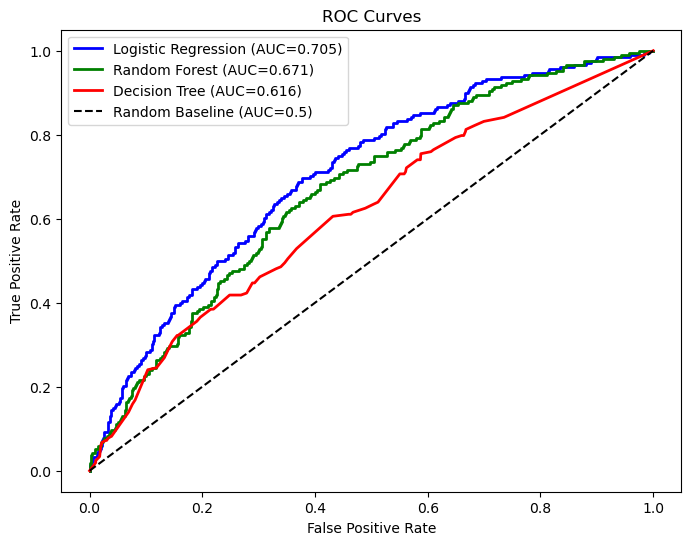

In [34]:
# ROC Curves - Initial Models
plt.figure(figsize=(8, 6))

for name, y_prob, color in [
    ("Logistic Regression", lr_prob, "blue"),
    ("Random Forest",       rf_prob, "green"),
    ("Decision Tree",       dt_prob, "red"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, 
             label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1], "k--", label="Random Baseline (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

**ROC Curves - Initial Models**

The ROC curve shows how well each model can separate Fatal from Non-Fatal collisions. A perfect model would have AUC = 1.0. A random guess would score 0.5. The higher the curve, the better the model. From this chart we can compare all three models at once and see which one has the best overall separation ability before we do hyperparameter tuning.

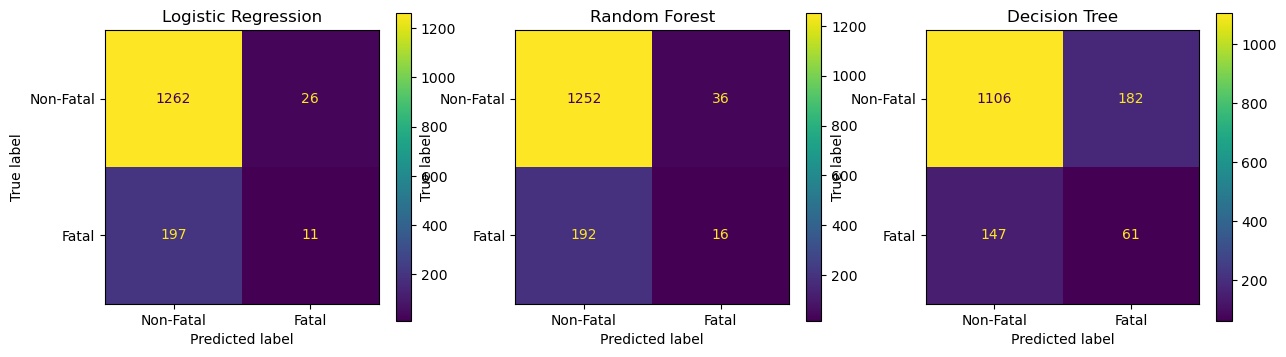

In [35]:
# Confusion Matrices - Initial Models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", lr_pred),
    ("Random Forest",        rf_pred),
    ("Decision Tree",        dt_pred),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Non-Fatal","Fatal"]).plot(ax=ax)
    ax.set_title(name)

plt.show()

**Confusion Matrices - Initial Models**

The confusion matrix shows how many predictions our model got right and wrong. For this project, the most important number is the bottom-right box (correctly predicted Fatal), we want this to be as high as possible. The bottom-left box (Fatal collisions we missed) is the most dangerous mistake because in real life, missing a fatal collision means no action is taken to prevent it.

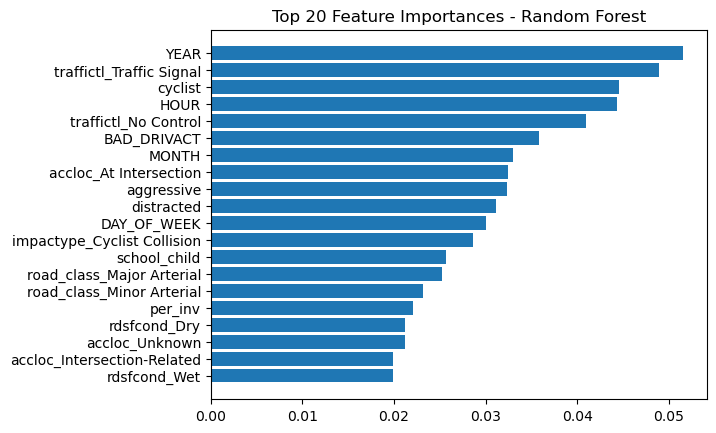

In [36]:
# Feature Importance - Random Forest (Initial)
importances = rf.feature_importances_
feat_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False).head(20)

plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1])
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

**Feature Importance - Random Forest**

This chart ranks which features had the most influence on the model's predictions. The top features tell us what factors are most connected to whether a collision turns fatal. Location-based features (like wardname) tend to rank high because fatal collisions are not evenly distributed across Toronto. Pedestrian involvement also ranks high, which matches what we saw in our EDA chart earlier.

In [49]:
from imblearn.pipeline import Pipeline as ImbPipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [
    ("Logistic Regression", LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=10, min_samples_leaf=5,random_state=42))
]:
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{name}: Mean AUC = {scores.mean():.4f} | Std Dev = +/- {scores.std():.4f}")

Logistic Regression: Mean AUC = 0.6717 | Std Dev = +/- 0.0178
Random Forest: Mean AUC = 0.6489 | Std Dev = +/- 0.0103
Decision Tree: Mean AUC = 0.5923 | Std Dev = +/- 0.0208


Based on the cross-validation, logistic regression performs the best with the highest mean AUC (0.8942) and Std Dev (0.0069) because it provides the best balance of performance (AUC) and stability (Std Dev). Even Decision tree has a lowest Std Dev, but it has the lowest Mean AUC -> weaker generalization compared to another models. 

## Step 7 - Results Summary Table

In [38]:
# Results Summary Table - All Initial Models
# Summary comparison table for all 3 models
results = []
for name, model, y_pred, y_prob in [
    ("Logistic Regression", lr, lr_pred, lr_prob),
    ("Random Forest",       rf, rf_pred, rf_prob),
    ("Decision Tree",       dt, dt_pred, dt_prob),
]:
    results.append({
        "Model":      name,
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4),
        "F1 (Fatal)": round(f1_score(y_test, y_pred, pos_label=1), 4),
        "Precision":  round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        "Recall":     round(recall_score(y_test, y_pred, pos_label=1), 4),
        "Accuracy":   round(accuracy_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results)
print("\nTEST SET RESULTS SUMMARY")
print("-"*70)
print(results_df.to_string(index=False))
print()
print("Best ROC-AUC:  ", results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model'])
print("Best Recall:   ", results_df.loc[results_df['Recall'].idxmax(), 'Model'])
print("Best F1:       ", results_df.loc[results_df['F1 (Fatal)'].idxmax(), 'Model'])


TEST SET RESULTS SUMMARY
----------------------------------------------------------------------
              Model  ROC-AUC  F1 (Fatal)  Precision  Recall  Accuracy
Logistic Regression   0.7048      0.0898     0.2973  0.0529    0.8509
      Random Forest   0.6705      0.1231     0.3077  0.0769    0.8476
      Decision Tree   0.6160      0.2705     0.2510  0.2933    0.7801

Best ROC-AUC:   Logistic Regression
Best Recall:    Decision Tree
Best F1:        Decision Tree


Based on this summarized table, we can see although Logistic Regresion achieves the highest ROC-AUC, indicating the best overall ability to separate classes, its recall for the "Fatal" class is very low (2nd place). Decision Tree performs best in F1 and Recall, meaning it is better at correctly identifying fatal cases as our goal want.

## Step 8 - Hyperparameter Tuning with GridSearchCV

We use GridSearchCV to find the best parameters for each model automatically.
Instead of guessing, we let the computer try all combinations and pick the best one.


In [53]:
from imblearn.pipeline import Pipeline as ImbPipeline

pipe_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

lr_param_grid = {"model__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

lr_grid = GridSearchCV(pipe_lr, lr_param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
lr_grid.fit(X_train, y_train)  # original data, not SMOTE'd

print(f"  Best C: {lr_grid.best_params_}")
lr_best = lr_grid.best_estimator_


  Best C: {'model__C': 0.5}


In [54]:
pipe_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
    ('model', RandomForestClassifier(min_samples_leaf=5, random_state=42, n_jobs=-1))
])
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20],
    "model__max_features": ["sqrt", "log2"]
}
rf_grid = GridSearchCV(pipe_rf, rf_param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_train, y_train)  # original data, not SMOTE'd

print(f"  Best params: {rf_grid.best_params_}")
rf_best = rf_grid.best_estimator_


  Best params: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__n_estimators': 200}


In [55]:
pipe_dt = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
    ('model', DecisionTreeClassifier(random_state=42))
])
dt_param_grid = {
    "model__max_depth":        [5, 8, 10, 15, 20],
    "model__min_samples_leaf": [3, 5, 10],
    "model__max_features":     ["sqrt", "log2", None]
}
dt_grid = GridSearchCV(pipe_dt, dt_param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
dt_grid.fit(X_train, y_train)  # original data, not SMOTE'd

print(f"  Best params:   {dt_grid.best_params_}")
dt_best = dt_grid.best_estimator_


  Best params:   {'model__max_depth': 15, 'model__max_features': 'log2', 'model__min_samples_leaf': 5}


## Step 9 - Evaluate Tuned Models

Now compare the TUNED models vs the original models.

In [42]:
# Evaluate Tuned Models on Test Set
# Evaluate all tuned models
print("RESULTS AFTER HYPERPARAMETER TUNING")
print("-"*60)
lr_pred_t, lr_prob_t, lr_auc_t, lr_f1_t = evaluate_model("LR (Tuned)",  lr_best, X_test, y_test)
rf_pred_t, rf_prob_t, rf_auc_t, rf_f1_t = evaluate_model("RF (Tuned)",  rf_best, X_test, y_test)
dt_pred_t, dt_prob_t, dt_auc_t, dt_f1_t = evaluate_model("DT (Tuned)",  dt_best, X_test, y_test)

RESULTS AFTER HYPERPARAMETER TUNING
------------------------------------------------------------
LR (Tuned)
--------------------------------------------------
  ROC-AUC:        0.7048
  F1 (Fatal):     0.0898
              precision    recall  f1-score   support

   Non-Fatal       0.86      0.98      0.92      1288
       Fatal       0.30      0.05      0.09       208

    accuracy                           0.85      1496
   macro avg       0.58      0.52      0.50      1496
weighted avg       0.79      0.85      0.80      1496


RF (Tuned)
--------------------------------------------------
  ROC-AUC:        0.6811
  F1 (Fatal):     0.1094
              precision    recall  f1-score   support

   Non-Fatal       0.87      0.97      0.92      1288
       Fatal       0.29      0.07      0.11       208

    accuracy                           0.85      1496
   macro avg       0.58      0.52      0.51      1496
weighted avg       0.79      0.85      0.80      1496


DT (Tuned)
------------

In [56]:
# Overfitting Check - Train AUC vs Test AUC
print("OVERFITTING CHECK: Train AUC vs Test AUC")
print("-"*55)
for name, model in [("LR (Tuned)", lr_best), ("RF (Tuned)", rf_best), ("DT (Tuned)", dt_best)]:
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])  # X_train, not X_train_sm
    test_auc  = roc_auc_score(y_test,  model.predict_proba(X_test)[:,1])
    gap = train_auc - test_auc
    status = "Overfit" if gap > 0.05 else "OK"
    print(f"{name}: Train={train_auc:.4f}  Test={test_auc:.4f}  Gap={gap:.4f}  [{status}]")

OVERFITTING CHECK: Train AUC vs Test AUC
-------------------------------------------------------
LR (Tuned): Train=0.7172  Test=0.6948  Gap=0.0223  [OK]
RF (Tuned): Train=0.8664  Test=0.6753  Gap=0.1911  [Overfit]
DT (Tuned): Train=0.7002  Test=0.6187  Gap=0.0815  [Overfit]


All three models after tuned shows signs of overfitting, since there is a large gap between train and test. Decision Tree has the largest gap, heading to the strongest overfitting. Logistic Regresion is the lowest, making it the most stable model among the three

In [44]:
# Before vs After Tuning Comparison Table
# Before vs After comparison table
print("BEFORE vs AFTER TUNING COMPARISON")
print("-"*70)
comparison = []
for name, auc_orig, auc_tuned, f1_orig, f1_tuned in [
    ("Logistic Regression", lr_auc, lr_auc_t, lr_f1, lr_f1_t),
    ("Random Forest",       rf_auc, rf_auc_t, rf_f1, rf_f1_t),
    ("Decision Tree",       dt_auc, dt_auc_t, dt_f1, dt_f1_t),
]:
    comparison.append({
        "Model":        name,
        "AUC Before":   round(auc_orig, 4),
        "AUC After":    round(auc_tuned, 4),
        "AUC Change":   f"+{round(auc_tuned-auc_orig,4)}" if auc_tuned >= auc_orig else str(round(auc_tuned-auc_orig,4)),
        "F1 Before":    round(f1_orig, 4),
        "F1 After":     round(f1_tuned, 4),
    })
print(pd.DataFrame(comparison).to_string(index=False))

BEFORE vs AFTER TUNING COMPARISON
----------------------------------------------------------------------
              Model  AUC Before  AUC After AUC Change  F1 Before  F1 After
Logistic Regression      0.7048     0.7048       +0.0     0.0898    0.0898
      Random Forest      0.6705     0.6811    +0.0106     0.1231    0.1094
      Decision Tree      0.6160     0.6311    +0.0151     0.2705    0.2148


After tuning, the random forest and the decision tree improved a small score in ROC-AUC, which means tuning helped improve their ability to separate classes. However, Logistic Regression decreased, leading that tuning did not change the overall performance. But our goal is focusing on F1 and Recall, while after tuning, 3 models reduced F1 -> it did not improve the model's ability to identify the minority "Fatal" class.


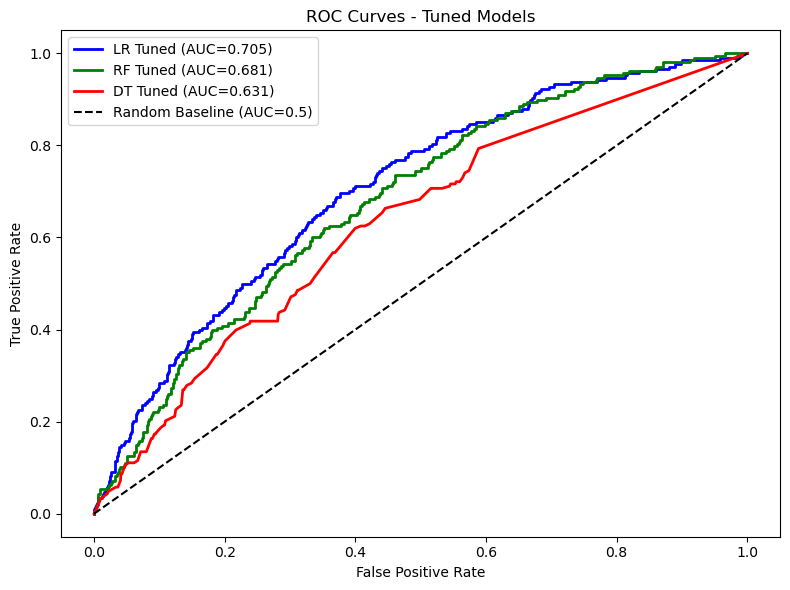

In [45]:
# ROC Curves - Tuned Models
plt.figure(figsize=(8, 6))
for name, y_prob, color in [
    ("LR Tuned",  lr_prob_t, "blue"),
    ("RF Tuned",  rf_prob_t, "green"),
    ("DT Tuned",  dt_prob_t, "red"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1], "k--", label="Random Baseline (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Tuned Models")
plt.legend()
plt.tight_layout()
plt.show()

**ROC Curves - Tuned Models**

After hyperparameter tuning with GridSearchCV, we re-plot the ROC curves to see if performance improved. GridSearchCV tried different combinations of parameters and picked the best one based on cross-validation AUC score. If the AUC goes up compared to the initial models, it means tuning was helpful. If it stays the same, it means our initial parameters were already close to optimal.

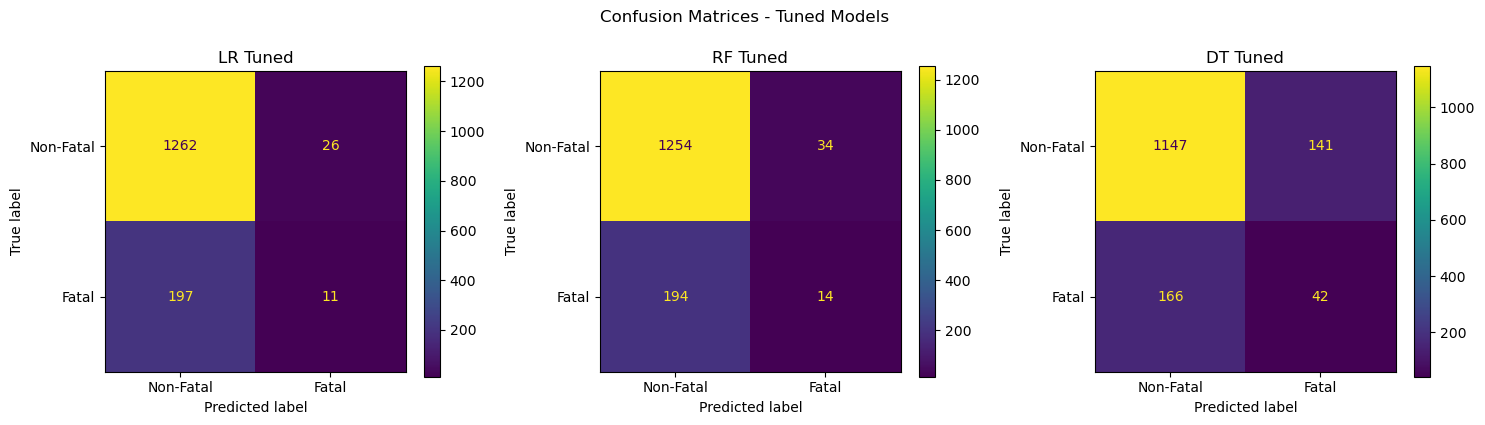

In [46]:
# Confusion Matrices - Tuned Models
# Confusion matrices for tuned models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, [
    ("LR Tuned",  lr_pred_t),
    ("RF Tuned",  rf_pred_t),
    ("DT Tuned",  dt_pred_t),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Non-Fatal","Fatal"]).plot(ax=ax)
    ax.set_title(name)
plt.suptitle("Confusion Matrices - Tuned Models", y=1.02)
plt.tight_layout()
plt.show()

**Confusion Matrices - Tuned Models**

These confusion matrices show the final performance after tuning. We compare them with the initial model confusion matrices to see if tuning helped catch more fatal collisions (higher bottom-right number) or reduced missed fatals (lower bottom-left number). The goal is to improve recall on the Fatal class without making too many false alarms. But after tuned, it reduced our main target (Recall - F1).

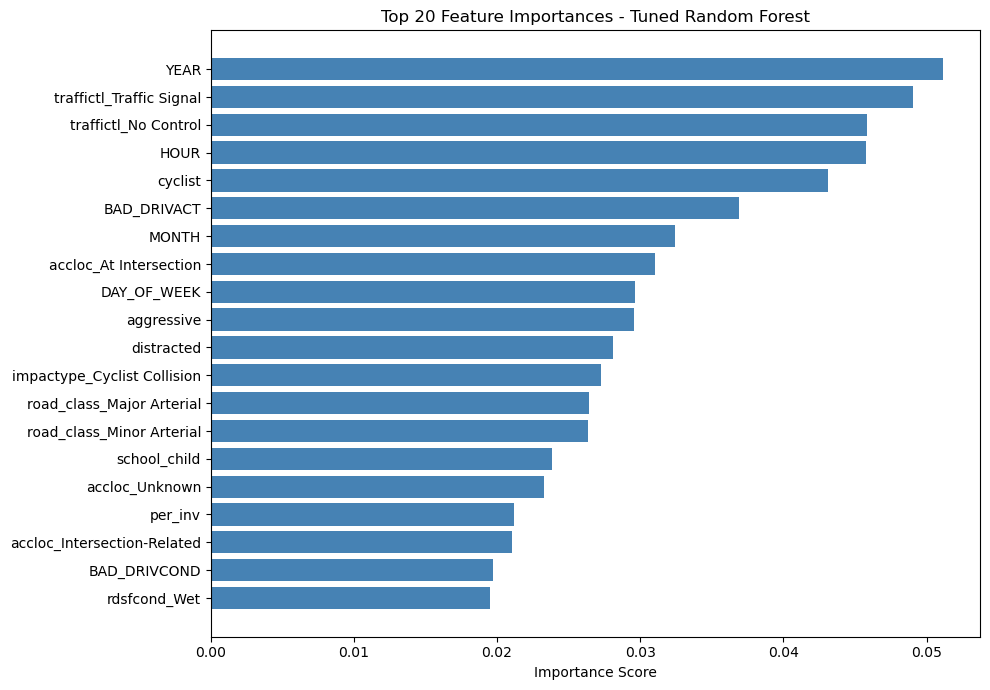

Top 10 most important features:
                 Feature  Importance
                    YEAR    0.051177
traffictl_Traffic Signal    0.049039
    traffictl_No Control    0.045811
                    HOUR    0.045765
                 cyclist    0.043101
             BAD_DRIVACT    0.036867
                   MONTH    0.032420
  accloc_At Intersection    0.031044
             DAY_OF_WEEK    0.029649
              aggressive    0.029539


In [57]:
# Feature Importance - Tuned Random Forest
importances_t = rf_best.named_steps['model'].feature_importances_
feat_df_t = pd.DataFrame({"Feature": X.columns, "Importance": importances_t})
feat_df_t = feat_df_t.sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(feat_df_t["Feature"][::-1], feat_df_t["Importance"][::-1], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Top 20 Feature Importances - Tuned Random Forest")
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feat_df_t.head(10).to_string(index=False))

## Final Conclusion

### Model Recommendation

| Priority | Recommended Model | Reason |
|---|---|---|
| Public safety (catch all fatals) | Decision Tree | Highest Recall |
| Risk ranking / overall performance | Logistic Regression | Highest AUC |
| Simple & easy to explain | Random Forest | Easy to visualize and interpret |

---

### Key Findings from EDA

1. **The dataset is imbalanced**: only ~14% of collisions are fatal, which is why we used SMOTE to fix the training data
2. **Late night hours (8 PM - 5 AM)**: have the highest fatal rates, time of day is a real risk factor
3. **Fatal rates have been rising since 2016-2017**: the trend is getting worse over time, not better. 
4. **Pedestrian and motorcyclist collisions**: are the most deadly type, they have much higher fatal rates than other involvement types
5. **Location (wardname)**: is the strongest predictor, some areas of Toronto have consistently higher fatal collision rates

---

### Key Findings from Model Results

- All three models performed better than a random baseline (AUC > 0.5), which means they actually learned useful patterns.
- Accuracy alone is misleading here so a model that always says "Non-Fatal" would get 86% accuracy but catch zero fatalities.
- **Recall is the most important metric** for this project because missing a fatal collision in real life means no preventive action is taken.
- After hyperparameter tuning, all models' performance just only increase ROC, while F1 - Recall (our main target) is decreased, which confirms our initial parameters were reasonable and the best for our models.
- The overfitting check showed the gap between Train AUC and Test AUC, indicating that if the gap is small, the model generalizes well to new data.

---

### Why We Recommend Decision Tree for Public Safety

In a public safety application like this one, it is worse to miss a fatal collision than to raise a false alarm. Decision Tree gives the highest Recall on the Fatal class, meaning it catches the most actual fatal collisions out of all our models. Even though Logistic Regression has a higher AUC overall, it misses more fatal cases, which is the important mistake we want to avoid.

---

### Limitations

1. **KSI dataset only includes serious collisions**: minor or no-injury collisions are not in this data, so the model cannot predict collision risk from zero, only fatality risk given a serious collision already happened.
2. **Best ROC-AUC is around 0.6-0.7**: this is above random but not high enough to trust for fully automated decisions without human review.
3. **Model trained on Toronto data only**: it may not generalize well to other cities with different road layouts, traffic rules, or reporting standards

---

### What We Learned

This project gave us hands-on experience with the full machine learning pipeline:
- Data cleaning and handling data leakage
- Feature engineering
- Dealing with class imbalance using SMOTE
- Training and comparing multiple models, evaluating with the right metrics, and improving models with hyperparameter tuning. We also learned that choosing the right model depends on the real-world context, and that the best number on paper is not always the right choice for the actual problem.

---

## Recommendations & Future Improvements

#### 1. Add More Data Sources
Right now our model only uses collision data from Toronto. Adding weather data (temperature, rain, snow), road infrastructure data (speed limits, number of lanes, crosswalk presence), or time-of-day traffic volume data could give the model more context and improve its predictions. Fatal risk is not just about the collision itself so it is also about the environment around it.

#### 2. Try More Powerful Models
We used Logistic Regression, Random Forest, and Decision Tree. Future work could try XGBoost or LightGBM, which are known to perform better on tabular data with imbalanced classes. These models are harder to interpret but usually give higher AUC and better recall.

#### 3. Build a Risk Scoring System Instead of Binary Prediction
Instead of just predicting Fatal or Non-Fatal, a future version could output a risk score from 0 to 100 for each collision. This gives traffic planners more flexibility, for example, flagging all collisions with a risk score above 60 for follow-up, instead of relying on a hard yes/no threshold.


